In [ ]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torchvision  # Imported and its version is printed below, but it is not otherwise used in this notebook

print(torch.__version__)
print(torchvision.__version__)

from torch import nn
import torch.nn.functional as F

2.3.1
0.18.1


In [ ]:
# Check whether a GPU is available and, if so, which type
if torch.cuda.is_available():
  print('Numero di GPU disponibili: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# If a GPU is available, set device='cuda', otherwise 'cpu'
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Numero di GPU disponibili:  1
NVIDIA GeForce GTX 970
Computation device: cuda



# Data Preprocessing

## Creating ```data``` and ```labels```

In [ ]:
import pandas as pd
# We created another csv file that contains a column called `new_name`,
# in which the class of each track is indicated with 0, 1, 2
labels_df = pd.read_csv('my_labels_0.csv')
file_names = labels_df['new_name'].to_list()

# We will notice that there are 5 tracks that do not have the required shape (1,64000)
# So we will need to redefine a labels vector that accounts for the missing tracks
# For now we create an array containing the labels of all 450 tracks
temp_labels = labels_df['label'].to_numpy()

In [ ]:
import torchaudio

# List that will contain the waveforms of all audio files
waveforms = []

# List that will contain the labels of the tracks, which will be ~445 and not 450
labels_lst = []

# The folder path is the same for all audio files
folder_path = 'gruppo_0/'

# Shape that the audio files must have
desired_shape = (1,64000)

# Loop over the audio files
for i, file_name in enumerate(file_names):

    # This gives us the path of the single audio file
    file_path = folder_path + file_name

    # Load the audio file (sample rate is not of interest)
    waveform, _ = torchaudio.load(file_path)

    # If the waveform has the required shape, we accept it
    if (waveform.shape==desired_shape):
        waveforms.append(waveform.float())
        # It is important to add the label of the track just selected
        labels_lst.append(temp_labels[i])

# Stack the audio files into a single tensor
data = torch.stack(waveforms)
labels = torch.Tensor(labels_lst).int()
print('data shape:   {} \t| tipo:   {}'.format(data.shape, data.dtype))
print('labels shape: {} \t\t| tipo: {}'.format(labels.shape, labels.dtype))

data shape:   torch.Size([445, 1, 64000]) 	| tipo:   torch.float32
labels shape: torch.Size([445]) 		| tipo: torch.int32


# Normalization [0, 1]

In [ ]:
# We create two tensors containing the maxima and minima along dimension 2 of the data tensor
# Dimension 2 corresponds to the waveform of the track
max_tensor = data.max(dim=2, keepdim=True)[0]
min_tensor = data.min(dim=2, keepdim=True)[0]
data = (data-min_tensor)/(max_tensor-min_tensor)
print(f'data shape: {data.shape}')

data shape: torch.Size([445, 1, 64000])


## Splitting the Tracks into Fragments

In [ ]:
# Each fragment will be 8000 points long, i.e. 0.5s
fragment_lenght = 8000

# The number of fragments must be obtained with an integer division
num_fragment = 64000 // fragment_lenght

# List that will contain the fragments of the tracks
fragmented_data_lst = []

# List that will contain the label of each fragment
fragmented_labels_lst = []

# We iterate over each track and each label
# We know that the i-th label corresponds to the i-th track
for (track, label) in  zip(data, labels):

    # We iterate over the number of fragments
    for j in range(num_fragment):
        # Slicing of the track
        start = j*fragment_lenght
        stop = (j+1)*fragment_lenght
        fragment = track[:, start:stop]

        # This check is superfluous if 64000 is a multiple of fragment_lenght
        # but becomes essential if ( 64000 % fragment_lenght ) is different from 0
        if fragment.shape==(1,fragment_lenght):
            fragmented_data_lst.append(fragment)
            fragmented_labels_lst.append(label)

# As before, we convert the lists into tensors
fragmented_data = torch.stack(fragmented_data_lst)
fragmented_labels = torch.stack(fragmented_labels_lst)

# We print the shapes of the new tensors to check that everything is in order
print('fragmented_data shape:  \t', fragmented_data.shape)
print('fragmented_labels shape:\t', fragmented_labels.shape)

fragmented_data shape:  	 torch.Size([3560, 1, 8000])
fragmented_labels shape:	 torch.Size([3560])


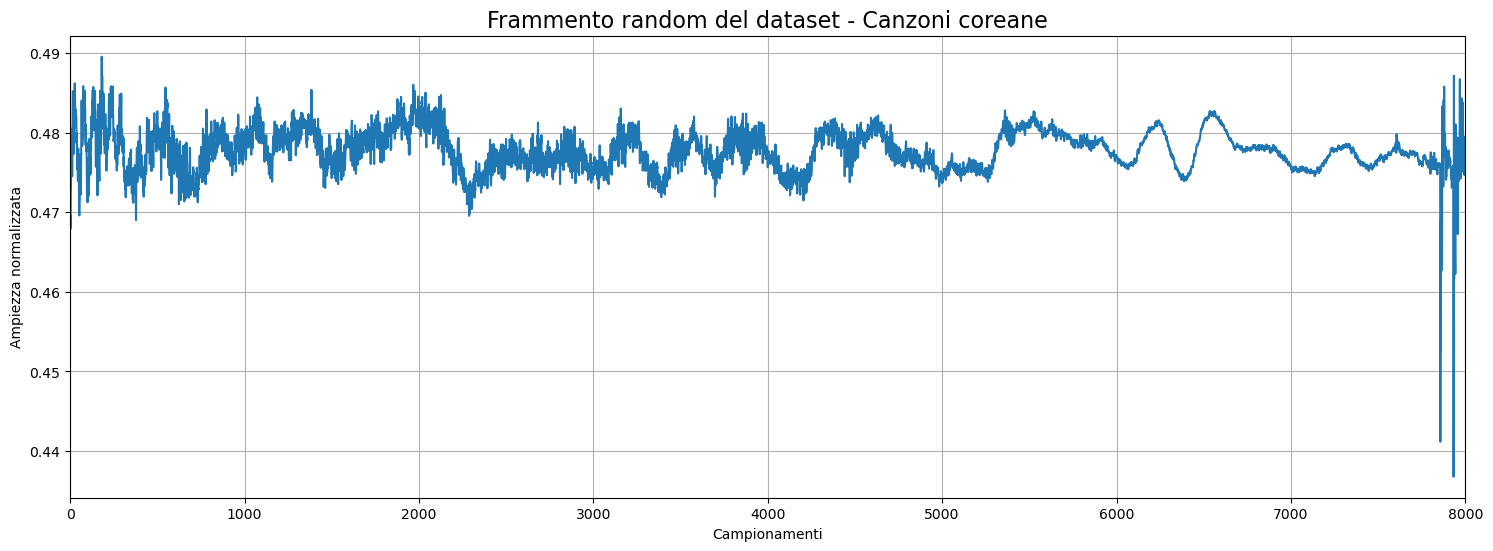

In [ ]:
# We plot a random fragment of the dataset to check that the normalization is correct
plt.figure(figsize=(18,6))
random_index = np.random.randint(0,fragmented_data.size(0))
categories = ['Rumore di uccelli', 'Canzoni coreane', 'Parlato Arabo']
plt.plot(fragmented_data[random_index,:,:].flatten())
plt.title(f'Frammento random del dataset - {categories[fragmented_labels[random_index]]}', size=16)
plt.xlabel('Campionamenti')
plt.ylabel('Ampiezza normalizzata')
plt.xlim(0,fragment_lenght)
plt.grid();

## Train-Validation Split and Dataloader Creation

We do not further split the dataset into a test set, for the following reasons:
- The validation set does not influence the model's training in any way. We use it only to monitor overfitting.
- As the test set, we will use the tracks in the test data folder.
- Splitting the training dataset further to carve out a test set would leave fewer samples available for training the model.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, random_split

batch_size = 64
train_ratio = 0.7 # Percentage of the data used for training


# First we load the full dataset containing all the FRAGMENTS
dataset = TensorDataset(fragmented_data, fragmented_labels)

# We split the dataset into train/validation
train_dataset, vali_dataset = random_split(dataset, [train_ratio, 1-train_ratio])

# We create the dataloaders
dl_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dl_vali  = DataLoader(vali_dataset,  batch_size=batch_size, shuffle=True, drop_last=True)


# Sizes of the datasets
print('Frammenti per il TRAIN:  \t',len(train_dataset))
print('Frammenti per la VALIDATION:\t',len(vali_dataset))

# Shape of a batch
xb, yb = next(iter(dl_train))
print('\nxb shape:\t',xb.shape)
print('yb shape:\t',yb.shape)

Frammenti per il TRAIN:  	 2492
Frammenti per la VALIDATION:	 1068

xb shape:	 torch.Size([64, 1, 8000])
yb shape:	 torch.Size([64])


# Defining the AE Model

In [ ]:
import torch
import torch.nn as nn

# AE parameters
channels = [1,4,8,16,32,64]
kernel_size = [40,30,20,10,5]
dilation = [1,1,2,2,2]
stride = [2,3,4,6,7]

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.convolution = nn.Sequential(
            nn.Conv1d(in_channels=channels[0], out_channels=channels[1], kernel_size=kernel_size[0], stride=stride[0], padding=1, dilation=dilation[0]),
            nn.BatchNorm1d(channels[1]),
            nn.ReLU(),

            nn.Conv1d(in_channels=channels[1], out_channels=channels[2], kernel_size=kernel_size[1], stride=stride[1], padding=1, dilation=dilation[1]),
            nn.BatchNorm1d(channels[2]),
            nn.ReLU(),

            nn.Conv1d(in_channels=channels[2], out_channels=channels[3], kernel_size=kernel_size[2], stride=stride[2], padding=1, dilation=dilation[2]),
            nn.BatchNorm1d(channels[3]),
            nn.ReLU(),

            nn.Conv1d(in_channels=channels[3], out_channels=channels[4], kernel_size=kernel_size[3], stride=stride[3], padding=1, dilation=dilation[3]),
            nn.BatchNorm1d(channels[4]),
            nn.ReLU(),


            nn.Conv1d(in_channels=channels[4], out_channels=channels[5], kernel_size=kernel_size[4], stride=stride[4], padding=1, dilation=dilation[4]),
            nn.BatchNorm1d(channels[5]),
            nn.ReLU(),
        )


    def forward(self, x):
        x = self.convolution(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.reverse_convolution = nn.Sequential(
            nn.ConvTranspose1d(in_channels=channels[-1],  out_channels=channels[-2], kernel_size=kernel_size[-1],  stride=stride[-1], padding=0, output_padding=0, dilation=dilation[-1]),
            nn.ReLU(),

            nn.ConvTranspose1d(in_channels=channels[-2],  out_channels=channels[-3], kernel_size=kernel_size[-2],  stride=stride[-2], padding=0, output_padding=2, dilation=dilation[-2]),
            nn.ReLU(),

            nn.ConvTranspose1d(in_channels=channels[-3],  out_channels=channels[-4],  kernel_size=kernel_size[-3],  stride=stride[-3], padding=0, output_padding=0, dilation=dilation[-3]),
            nn.ReLU(),

            nn.ConvTranspose1d(in_channels=channels[-4],  out_channels=channels[-5],  kernel_size=kernel_size[-4],  stride=stride[-4], padding=1, output_padding=0, dilation=dilation[-4]),
            nn.ReLU(),

            nn.ConvTranspose1d(in_channels=channels[-5],  out_channels=channels[-6],  kernel_size=kernel_size[-5],  stride=stride[-5], padding=1, output_padding=0, dilation=dilation[-5]),
            nn.Sigmoid(), # A sigmoid is important here, not a ReLU
        )


    def forward(self, x):

        x = self.reverse_convolution(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [ ]:
# To obtain reproducible results and ensure better convergence of the loss, all the model's weights are initialized.
import torch.nn.init as init

# We initialize the models
encoder = Encoder()
decoder = Decoder()
model_ae = Autoencoder(encoder, decoder)

# Weight initialization function
def initialize_weights(m):
    if isinstance(m, nn.Conv1d) or isinstance(m, nn.ConvTranspose1d):
        init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0)
    # We also account for the case in which the model may have linear layers
    elif isinstance(m, nn.Linear):
        init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            init.constant_(m.bias, 0)

# Applying the initialization function to all the layers of the model
model_ae.apply(initialize_weights);

In [ ]:
# We print the summary of our model
input_size = (1,fragment_lenght)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model_ae.cuda(), input_size=input_size)
else:
  summary(model_ae, input_size=input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 4, 3982]             164
       BatchNorm1d-2              [-1, 4, 3982]               8
              ReLU-3              [-1, 4, 3982]               0
            Conv1d-4              [-1, 8, 1319]             968
       BatchNorm1d-5              [-1, 8, 1319]              16
              ReLU-6              [-1, 8, 1319]               0
            Conv1d-7              [-1, 16, 321]           2,576
       BatchNorm1d-8              [-1, 16, 321]              32
              ReLU-9              [-1, 16, 321]               0
           Conv1d-10               [-1, 32, 51]           5,152
      BatchNorm1d-11               [-1, 32, 51]              64
             ReLU-12               [-1, 32, 51]               0
           Conv1d-13                [-1, 64, 7]          10,304
      BatchNorm1d-14                [-1

In [ ]:
# Move all models to GPU
model_ae = model_ae.to(device)
encoder = encoder.to(device)
decoder = decoder.to(device)

# Let's test it on a batch
xb, yb = next(iter(dl_train))
xb = xb.to(device)
xb_recon, _ = model_ae(xb)
z = encoder(xb)
# The latent representation z is a matrix (64 channels x 7 time steps) per sample, deliberately
# not flattened into a vector. Later, adaptive_avg_pool1d is used to obtain a fixed-size vector
# from it (e.g. for visualization/clustering).
print('xb_recon shape:\t',xb_recon.shape)
print('z shape:\t',z.shape)

xb_recon shape:	 torch.Size([64, 1, 8000])
z shape:	 torch.Size([64, 64, 7])


# Training

## Defining the Loss, Optimizer, and Learning Rate

In [ ]:
import torch.optim as optim
lr = 1e-3
# We choose the Huber Loss as the cost function
criterion = nn.HuberLoss(reduction='mean',delta=1)

# We choose the Adam optimizer and set weight_decay to reduce the risk of overfitting,
# encouraging the model to keep smaller weights.
optimizer = optim.Adam(model_ae.parameters(), lr=lr, weight_decay=1e-5)

## Loop

In [ ]:
# Training loop
import time

epochs = 400
hist_loss = []
hist_vloss = []

for epoch in range(epochs):
    t0 = time.time()
    train_loss = 0
    train_vloss = 0  # Initialized but never updated/used below; the actual validation loss is tracked in vali_loss
    counter = 0

    # Train step
    model_ae.train()
    for xb, _ in (dl_train):
        counter+=1
        xb = xb.to(device)
        xhat, _ = model_ae(xb) # We are not interested in the model's second output, i.e. the latent space
        loss = criterion(xb,xhat)
        train_loss += loss.item()

        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= counter
    hist_loss.append(train_loss)

    # Validation step (the weights are not updated)
    model_ae.eval()
    vali_loss = 0
    counter = 0
    with torch.no_grad():
      for xb, _ in dl_vali:
        counter += 1
        xb=xb.to(device)
        xhat, _ = model_ae(xb)
        vloss = criterion(xb, xhat)
        vali_loss += vloss.item()

    vali_loss /= counter
    hist_vloss.append(vali_loss)


    elapsed_time = time.time()-t0
    print("epoch: %d, \ttime(s): %.4f, \ttrain loss: %.6f, \tvali loss: %.6f" % (epoch+1, elapsed_time, train_loss, vali_loss))

epoch: 1, 	time(s): 0.9382, 	train loss: 0.008144, 	vali loss: 0.007759
epoch: 2, 	time(s): 0.7964, 	train loss: 0.007481, 	vali loss: 0.007210
epoch: 3, 	time(s): 0.7947, 	train loss: 0.007189, 	vali loss: 0.006966
epoch: 4, 	time(s): 0.7969, 	train loss: 0.006890, 	vali loss: 0.006591
epoch: 5, 	time(s): 0.8010, 	train loss: 0.006667, 	vali loss: 0.006463
epoch: 6, 	time(s): 0.7866, 	train loss: 0.006479, 	vali loss: 0.006194
epoch: 7, 	time(s): 0.7885, 	train loss: 0.006303, 	vali loss: 0.006038
epoch: 8, 	time(s): 0.8156, 	train loss: 0.006162, 	vali loss: 0.006110
epoch: 9, 	time(s): 0.7917, 	train loss: 0.006092, 	vali loss: 0.005984
epoch: 10, 	time(s): 0.7916, 	train loss: 0.005987, 	vali loss: 0.005895
epoch: 11, 	time(s): 0.7970, 	train loss: 0.005895, 	vali loss: 0.005912
epoch: 12, 	time(s): 0.7965, 	train loss: 0.005814, 	vali loss: 0.005701
epoch: 13, 	time(s): 0.7890, 	train loss: 0.005643, 	vali loss: 0.005488
epoch: 14, 	time(s): 0.8083, 	train loss: 0.005433, 	vali lo

In [ ]:
# Save the model and print the loss (if needed)
# Disabled by default (if 0); see the next cell (if 1) to load the checkpoint instead
if 0:
    path = './salvataggi/22_giugno/1/'
    torch.save(model_ae, path+'model_ae.pt')
    with open(path+'loss_results_model_ae.txt','w') as file:
      for epoch in range(epochs):
        file.write(f'{epoch+1}\t{hist_loss[epoch]}\t{hist_vloss[epoch]}\n')

In [ ]:
# Load the model (if needed)
if 1:
    path = './salvataggi/22_giugno/1/' # Enter here the path of the folder where the files are located
    # This checkpoint is included in the repository at this exact relative path, so loading works out of the box

    # These two files were also submitted/delivered
    model_path = path + 'model_ae.pt'
    loss_file_path = path + 'loss_results_model_ae.txt'
    model_ae = torch.load(model_path)
    hist_loss, hist_vloss = np.loadtxt(loss_file_path,usecols=(1,2),unpack=True)
    epochs = hist_loss.size # If the training cell has not been run, the epochs variable is not defined
    np.random.seed(2745786977)
    torch.manual_seed(838118157274700)

    # Print the model we imported
    print(model_ae)

Autoencoder(
  (encoder): Encoder(
    (convolution): Sequential(
      (0): Conv1d(1, 4, kernel_size=(40,), stride=(2,), padding=(1,))
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv1d(4, 8, kernel_size=(30,), stride=(3,), padding=(1,))
      (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv1d(8, 16, kernel_size=(20,), stride=(4,), padding=(1,), dilation=(2,))
      (7): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv1d(16, 32, kernel_size=(10,), stride=(6,), padding=(1,), dilation=(2,))
      (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
      (12): Conv1d(32, 64, kernel_size=(5,), stride=(7,), padding=(1,), dilation=(2,))
      (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

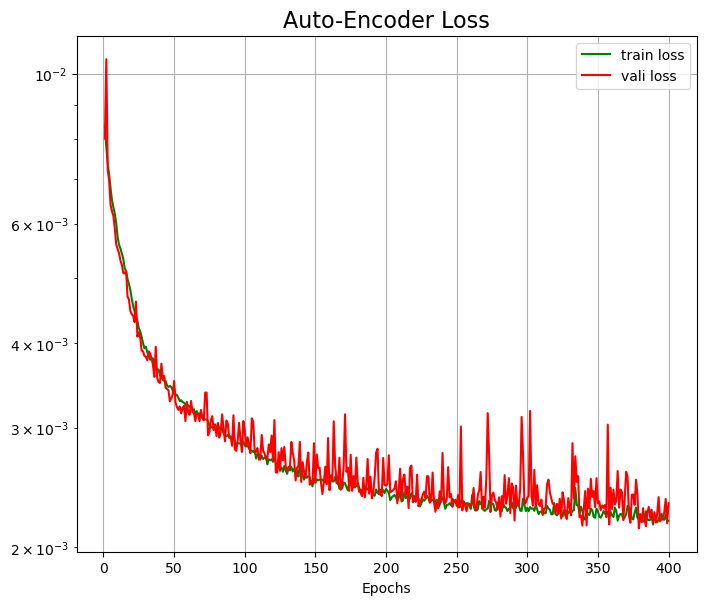

<Figure size 640x480 with 0 Axes>

In [ ]:
# training loss plot
plt.figure(figsize=(8,6.7))
plt.plot(np.arange(epochs)+1, hist_loss,  '-', color='green', label='train loss')
plt.plot(np.arange(epochs)+1, hist_vloss, '-', color='red',   label='vali loss')
plt.xlabel('Epochs')
plt.yscale('log')
plt.title('Auto-Encoder Loss', size=16)
plt.legend()
plt.grid()
plt.show()
plt.savefig('fig/loss.pdf');

# Performance

- The reconstruction and the estimation of the associated error are computed only on the **validation** fragments, and the same holds for the clustering of the latent space.
- Each fragment has a latent-space representation given by a matrix $z$ of size 64x7. To visualize the latent space, we apply an `adaptive_avg_pool1d` layer to $z$, which effectively averages over the second dimension (the one of length 7) and returns a vector of 64 elements. We will use this vector to show the clustering of the latent space.

In [ ]:
# List that will contain the reconstructed validation fragments
X_recon = []
# List that will contain the original fragments
X = []
# List that will contain the labels for all fragments in X and X_recon
y = []
# List that will contain the representation of the latent space
Z = []

# We modify the validation dataloader so that it has batch size equal to 1
dl_vali  = DataLoader(vali_dataset, batch_size=1, shuffle=False, drop_last=False)

model_ae.eval()
with torch.no_grad():
  for xb, yb in dl_vali:
    xb = xb.to(device)

    # The model reconstructs the track and provides the latent space
    xb_recon, z = model_ae(xb)

    # We apply average pooling to each track in the z space
    z=F.adaptive_avg_pool1d(z,1)

    # We flatten the latent space, the reconstructed track, and the original track
    z = z.view(1,-1)
    xb_recon = xb_recon.view(xb_recon.size(0),-1)
    xb = xb.view(xb.size(0),-1)

    # We add everything to the lists
    Z.append(z)
    X.append(xb)
    X_recon.append(xb_recon)
    y.append(yb.item()) # This last one is the track's label

# We convert the lists into tensors
Z = torch.cat(Z)
X = torch.cat(X)
X_recon = torch.cat(X_recon)
y = torch.Tensor(y)

# We convert all tensors into numpy arrays
Z, X, X_recon, y = Z.cpu().numpy(), X.cpu().numpy(), X_recon.cpu().numpy(), y.cpu().numpy()

# We check that the shapes are correct
print(f'shape di Z: {Z.shape}')
print(f'shape di X: {X.shape}')
print(f'shape di X_recon: {X_recon.shape}')
print(f'shape di y: {y.shape}')

shape di Z: (1068, 64)
shape di X: (1068, 8000)
shape di X_recon: (1068, 8000)
shape di y: (1068,)


## Reconstruction of a Fragment

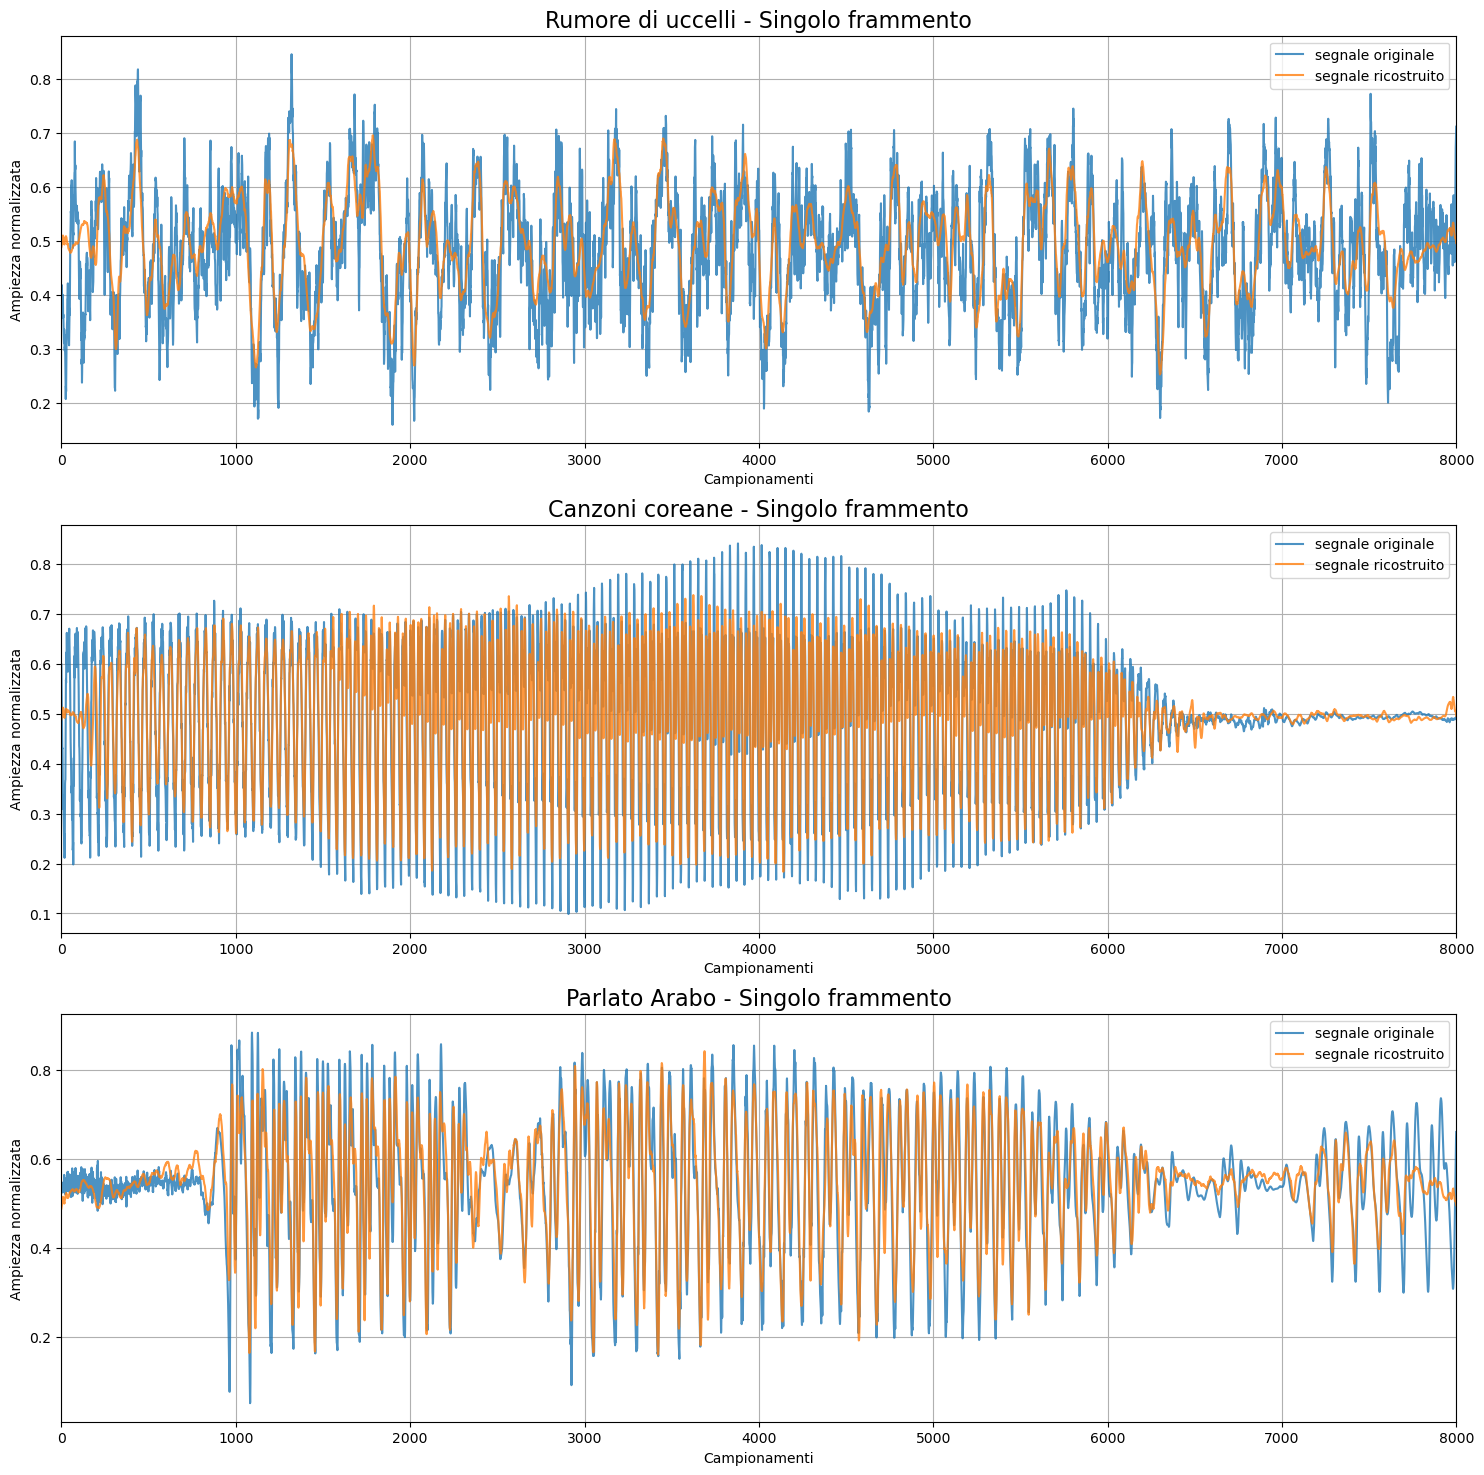

In [ ]:
# We choose a fragment to reconstruct for each category (Bird, Korean songs, Arabic)
random_number=99
plt.figure(figsize=(18,18))

# We iterate over the three main categories --> target = 0,1,2
for target in range(3):
    index = torch.nonzero(fragmented_labels==target)[random_number].item()
    categories = ['Rumore di uccelli', 'Canzoni coreane', 'Parlato Arabo']

    with torch.no_grad():
        x_temp = fragmented_data[index]
        x_temp = x_temp.view(1,1,fragment_lenght)
        x_temp = x_temp.to(device)
        x_temp = x_temp
        x_temp_recon,_ = model_ae(x_temp)

    x = x_temp.flatten().cpu().numpy()
    x_recon = x_temp_recon.flatten().cpu().numpy()
    plt.subplot(3,1,target+1)
    plt.plot(x, label='segnale originale',alpha=0.8)
    plt.plot(x_recon, label='segnale ricostruito',alpha=0.8)
    plt.title(f'{categories[target]} - Singolo frammento', size=16)
    plt.xlim(0,fragment_lenght)
    plt.xlabel('Campionamenti')
    plt.ylabel('Ampiezza normalizzata')
    plt.legend()
    plt.grid()

## Reconstruction Error

In [ ]:
# X and X_recon are organized as (fragment, sample)
# so the following arrays contain the point-by-point squared error for each fragment
loss0_array =  (X_recon[y==0]-X[y==0])**2
loss1_array =  (X_recon[y==1]-X[y==1])**2
loss2_array =  (X_recon[y==2]-X[y==2])**2

# The associated error is the point-by-point squared error averaged over the number of points (8000)
loss0 = np.mean(loss0_array, axis=1)
loss1 = np.mean(loss1_array, axis=1)
loss2 = np.mean(loss2_array, axis=1)

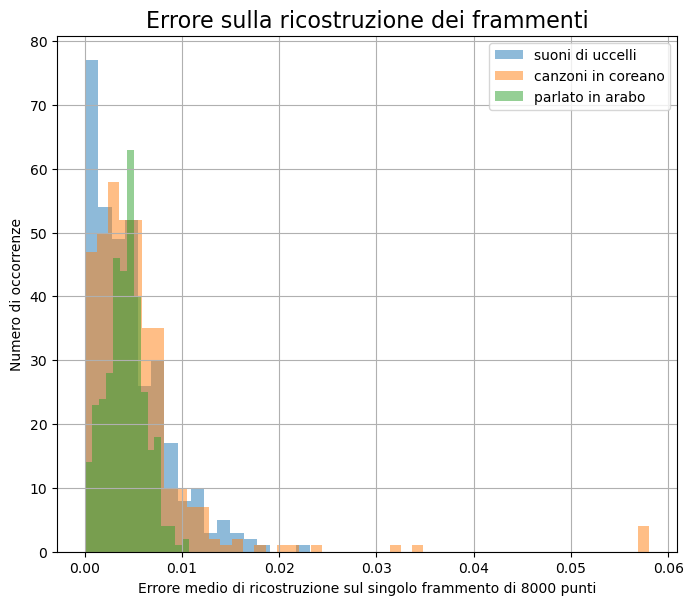

In [ ]:
# We show the reconstruction error for the 3 classes
plt.figure(figsize=(8, 6.7))
plt.title('Errore sulla ricostruzione dei frammenti', size=16)
plt.hist(loss0,alpha=0.5,label='suoni di uccelli', bins='auto',histtype='stepfilled')
plt.hist(loss1,alpha=0.5,label='canzoni in coreano', bins='auto',histtype='stepfilled')
plt.hist(loss2,alpha=0.5,label='parlato in arabo', bins='auto',histtype='stepfilled')
plt.xlabel(f'Errore medio di ricostruzione sul singolo frammento di {fragment_lenght} punti')
plt.ylabel('Numero di occorrenze')
plt.legend()
plt.xlim()
plt.grid();

## Clustering of the Latent Space (Fragments)

To show the representation of the fragments' latent space, we perform a dimensionality reduction from 64 to 2 using UMAP.

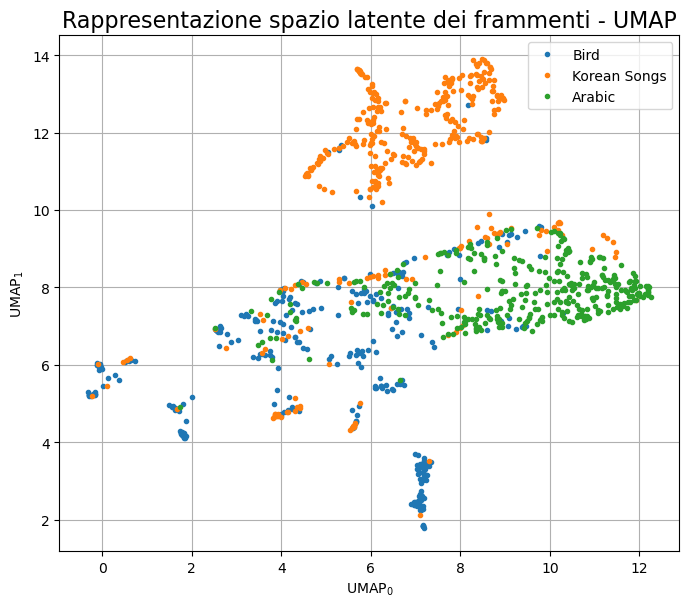

In [ ]:
import umap.umap_ as umap
import warnings
warnings.simplefilter('ignore')

umap = umap.UMAP(n_neighbors=15, n_components=2, random_state=2002)
umap_results = umap.fit_transform(Z)

plt.figure(figsize=(8, 6.7))
plt.plot(umap_results[y==0, 0], umap_results[y==0, 1], '.',
         umap_results[y==1, 0], umap_results[y==1, 1], '.',
         umap_results[y==2, 0], umap_results[y==2, 1], '.', )
plt.title('Rappresentazione spazio latente dei frammenti - UMAP', size=16);
plt.xlabel("UMAP$_0$")
plt.ylabel("UMAP$_1$")
plt.legend(['Bird', 'Korean Songs', 'Arabic'])
plt.grid();

## Clustering of the Latent Space (Tracks)

Instead of representing the latent space given by the tracks' fragments, in this section we represent the latent space of the whole tracks.

Indeed, if we feed an entire track (64000 points) into our model, we obtain a latent-space representation given by a matrix of size 64x62, to which we apply an `adaptive_avg_pool1d` layer to obtain a vector of size 64.

data shape:  	torch.Size([445, 1, 64000])
labels shape:	torch.Size([445])
Z_track shape:  	(445, 64)


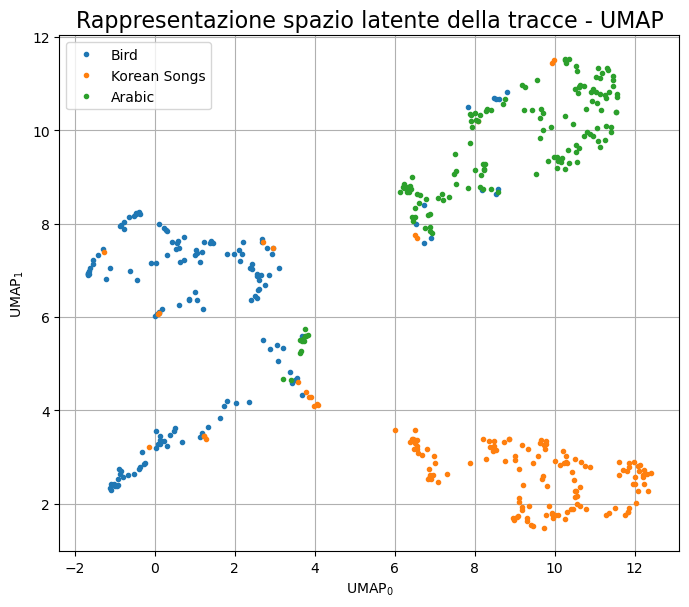

In [ ]:
import umap.umap_ as umap

# We check that data and labels have the correct shapes
# indeed these two variables were defined at the beginning of the notebook
print(f'data shape:  \t{data.shape}')
print(f'labels shape:\t{labels.shape}')

# List that will contain the representation of the tracks' latent space
Z_track_list = []

model_ae.eval()
with torch.no_grad():
    for track in data:
        track = track.view(1,1,-1)
        track = track.to(device)
        _, z_track = model_ae(track)
        z_track = F.adaptive_avg_pool1d(z_track,1)
        Z_track_list.append(z_track)

Z_track = torch.cat(Z_track_list) # Here Z_track comes out with shape (445,64,1)
Z_track = Z_track.view(Z_track.size(0), Z_track.size(1)) # This reshaping gives us the desired shape
Z_track = Z_track.cpu().numpy()
print(f'Z_track shape:  \t{Z_track.shape}')


# We apply a dimensionality reduction from 64 to 2 as done before.
umap_tracks = umap.UMAP(n_neighbors=10, n_components=2, random_state=2002)
umap_tracks_results = umap_tracks.fit_transform(Z_track)

# We plot the representation of the latent space
plt.figure(figsize=(8, 6.7))
plt.title('Rappresentazione spazio latente della tracce - UMAP', size=16)
plt.plot(umap_tracks_results[labels==0, 0], umap_tracks_results[labels==0, 1], '.',
        umap_tracks_results[labels==1, 0], umap_tracks_results[labels==1, 1], '.',
        umap_tracks_results[labels==2, 0], umap_tracks_results[labels==2, 1],'.')
plt.xlabel("UMAP$_0$")
plt.ylabel("UMAP$_1$")
plt.legend(['Bird', 'Korean Songs', 'Arabic'])
plt.grid()
plt.savefig('fig/tracks_latent_space.pdf')

# Anomaly detection

## Reconstruction of Test Tracks and Their Representation in the Latent Space

In [ ]:
# IMPORTING THE TRACKS
import os
import torchaudio

directory_path = 'gruppo_4' # Folder name (test data)
waveforms=[] # List that will contain all the tracks

# We save the track names in a list
# this will be useful later when we need to indicate the anomalous tracks
track_names = os.listdir(directory_path)
track_names = np.array(track_names) # It will be useful to have it as a numpy array

# Iterate over the files in the folder
for file_name in track_names:
    file_path = directory_path + '/' + file_name # Build the full path of the file
    waveform, _ = torchaudio.load(file_path)     # Load the audio file
    waveforms.append(waveform) # Add the audio tensor to the list

# We already used the name data earlier;
# to distinguish these tracks from those in the training data folder (gruppo_0), we give this one another name
data_test_pt = torch.stack(waveforms)

# As done also for the training data folder (gruppo_0) tracks, we normalize them from 0 to 1
# We are not interested in saving the max_tensor and min_tensor values
# We also specify that data_test is stored in a pytorch tensor
max_tensor = data_test_pt.max(dim=2, keepdim=True)[0]
min_tensor = data_test_pt.min(dim=2, keepdim=True)[0]
data_test_pt = (data_test_pt-min_tensor)/(max_tensor-min_tensor)

In [ ]:
# These parameters must be the same as those used during training
# We redefine them here just to be safe
fragment_lenght = 8000
num_fragment = 64000 // fragment_lenght

# For each FRAGMENT we will store the reconstruction error
loss_test_list = []

# This will be the list containing the reconstruction of the tracks
recon_data_test_lst = []

# For each FRAGMENT we will store its representation in the latent space
Z_test_lst = []

# We switch to eval mode and do not update the model's gradients
model_ae.eval() # Already set previously, we rewrite it just to be safe
with torch.no_grad():

# We iterate over each of the ~100 tracks
# each track will be called track
    for track in data_test_pt:
        # The goal is to reconstruct the single track (64000 points),
        # progressively adding the reconstruction of each fragment (8000 points)
        recon_track_lst = []

        # We run the model on each fragment
        for j in range(num_fragment):
            start = j*fragment_lenght
            stop = (j+1)*fragment_lenght
            fragment = track[:, start:stop]
            fragment = fragment.view(1,1,fragment_lenght) # we change the fragment's shape so it can be fed to the model
            fragment = fragment.to(device)  # We move the tensor to the GPU
            recon_fragment, z_fragment = model_ae(fragment) # The model performs the reconstruction

            # We store the reconstruction error for the single fragment
            # Error defined the same way as in the `Performance -> Reconstruction Error` section
            loss_test = (fragment-recon_fragment)**2
            loss_test = torch.mean(loss_test)
            loss_test_list.append(loss_test.item())

            # We store the representation of the latent space
            # It is essential to perform global average pooling on the latent space
            z_fragment=F.adaptive_avg_pool1d(z_fragment,1)
            z_fragment = z_fragment.view(1,-1)
            Z_test_lst.append(z_fragment)

            # We add the just-reconstructed fragment to the track
            recon_track_lst.append(recon_fragment)

        # Once all fragments of a track have been reconstructed,
        # we concatenate the fragments to obtain the whole track (recon_track)
        recon_track = torch.cat(recon_track_lst, dim=2)

        # `recon_track` is added to the list of all reconstructed tracks
        recon_data_test_lst.append(recon_track)

# We convert the list of reconstructed tracks into a pytorch tensor
recon_data_test_pt = torch.cat(recon_data_test_lst)

# We convert the list of latent-space representations into a pytorch tensor
Z_test = torch.cat(Z_test_lst)

# Conversion to numpy array, and we specify that these are numpy arrays
recon_data_test_np = recon_data_test_pt.cpu().numpy()
data_test_np = data_test_pt.cpu().numpy()

# We convert to numpy array without worrying about renaming the variables
Z_test = Z_test.cpu().numpy()
loss_test = np.array(loss_test_list)

# We print the shapes of the variables to check that everything is in order
# Z_test has first dimension 568, since it refers to track fragments and not whole tracks
print('recon data test:\t {}'.format(recon_data_test_np.shape))
print('data test:      \t {}'.format(data_test_np.shape))
print('Z test:         \t {}'.format(Z_test.shape))

recon data test:	 (71, 1, 64000)
data test:      	 (71, 1, 64000)
Z test:         	 (568, 64)


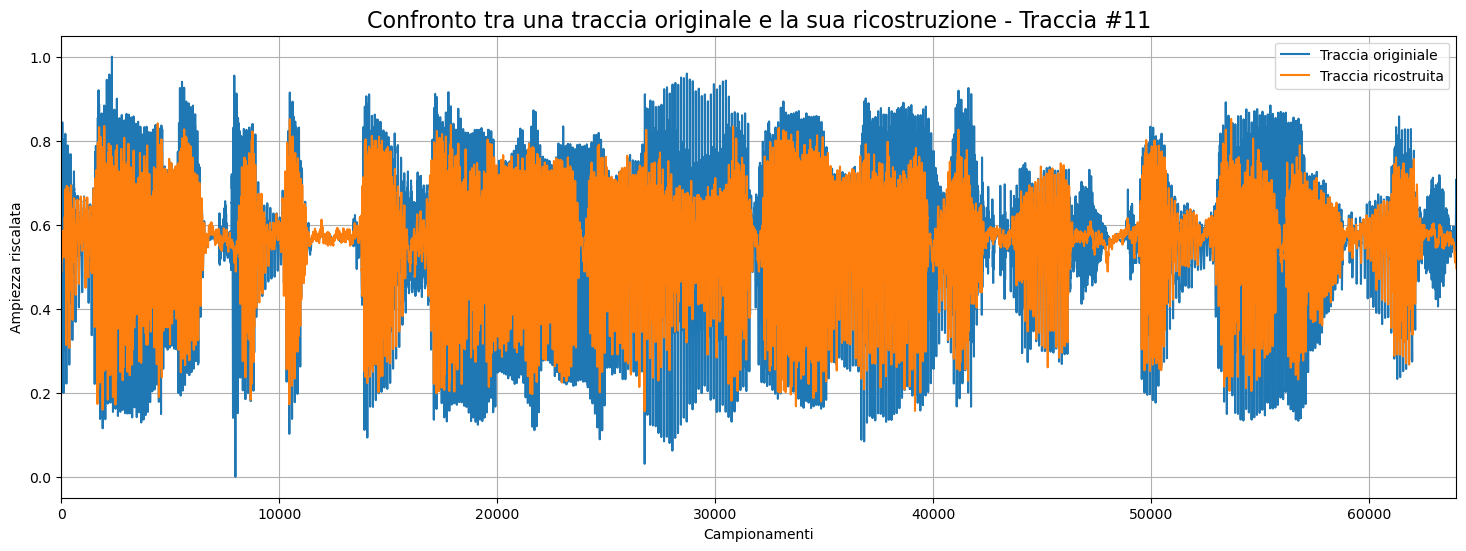

In [ ]:
# We check that the tracks are reconstructed well
random_track = 11
plt.figure(figsize=(18,6))
plt.plot(data_test_np[random_track,0,:], label='Traccia originiale')
plt.plot(recon_data_test_np[random_track,0,:], label='Traccia ricostruita')
plt.legend()
plt.xlim(0,64e3)
plt.grid()
plt.title(f'Confronto tra una traccia originale e la sua ricostruzione - Traccia #{random_track}', size=16)
plt.xlabel('Campionamenti')
plt.ylabel('Ampiezza riscalata');

## Reconstruction Error on the **Test** Fragments

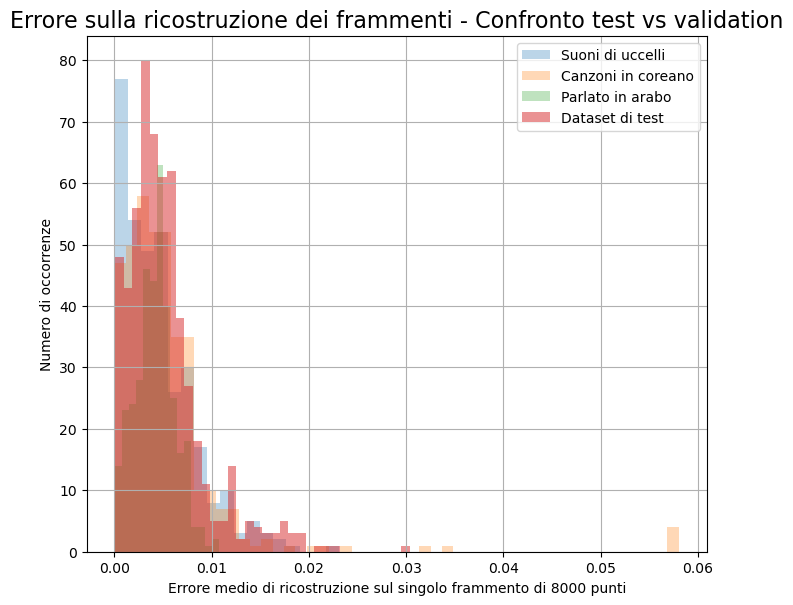

In [ ]:
# We show the reconstruction error on the TEST fragments compared to the VALIDATION ones
plt.figure(figsize=(8, 6.7))
plt.title('Errore sulla ricostruzione dei frammenti - Confronto test vs validation', size=16)

plt.hist(loss0, alpha=0.3,label='Suoni di uccelli', bins='auto',histtype='stepfilled')
plt.hist(loss1, alpha=0.3,label='Canzoni in coreano', bins='auto',histtype='stepfilled')
plt.hist(loss2, alpha=0.3,label='Parlato in arabo', bins='auto',histtype='stepfilled')
plt.hist(loss_test, alpha = 0.5, label='Dataset di test', bins='auto')

plt.xlabel(f'Errore medio di ricostruzione sul singolo frammento di {fragment_lenght} punti')
plt.ylabel('Numero di occorrenze')
plt.legend()
plt.xlim()
plt.grid();

## MSE Method for Anomaly Detection

We compute the MSE on the tracks and plot its distribution; we consider as anomalous the tracks that lie beyond 3 sigma from the mean.

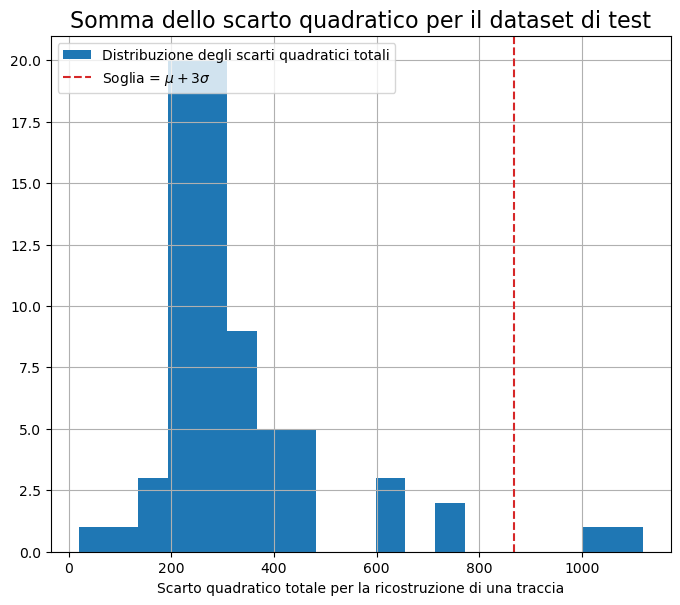

In [ ]:
# MSE
MSE_test = np.sum((data_test_np-recon_data_test_np)**2, axis=2).flatten()
MSE_test_mean = np.mean(MSE_test) # mu
MSE_test_std = np.std(MSE_test) # sigma

# The anomalous tracks are those that lie 3 sigma away from the mean
anomaly_indices = np.where(MSE_test>(MSE_test_mean+MSE_test_std*3))[0]

# Plot
plt.figure(figsize=(8,6.7))
plt.hist(MSE_test, bins='auto', label='Distribuzione degli scarti quadratici totali')
plt.title('Somma dello scarto quadratico per il dataset di test', size=16)
plt.xlabel('Scarto quadratico totale per la ricostruzione di una traccia')
plt.grid()
plt.axvline(MSE_test_mean+MSE_test_std*3, linestyle='--', label='Soglia = $\mu+3\sigma$', color='tab:red')
plt.legend(loc='upper left');

In [ ]:
# We show the names of the anomalies found
track_names = np.array(track_names)
track_names[anomaly_indices].reshape(-1,1)

array([['njNHvlbHhYL1MCr.wav'],
       ['VtEpwxy4yo9Y3A0.wav']], dtype='<U19')

Listening to the tracks, we can confirm that they are indeed anomalies. However, the method proposed below (based on clustering the latent space) manages to find many more anomalies.

## K-Means Cluster (Anomaly Detection)

- We apply a dimensionality reduction to the latent space of the test fragments `Z_test`.
- Plotting the tSNE, we notice that the data are distributed across 3 "groups", which we then cluster using the KMEANS method.
- Observing the clusters, we identify initial centers `initial_centers` to help the algorithm converge better.

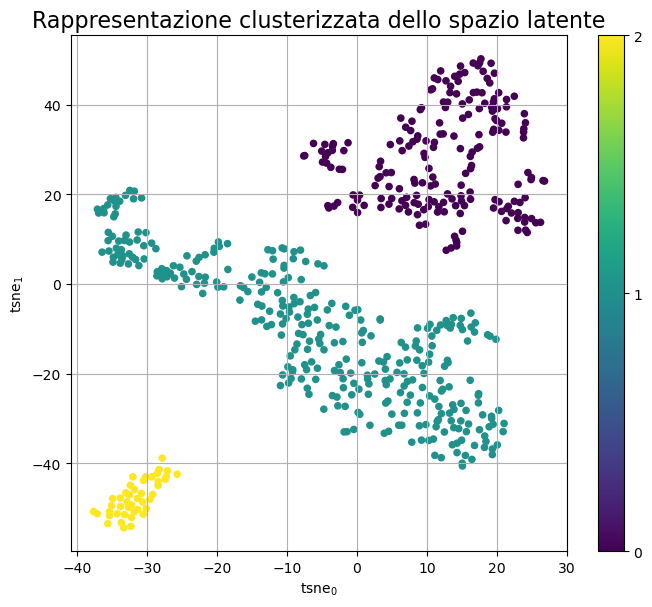

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import warnings
warnings.simplefilter('ignore')

# TSNE of the latent space
tsne_test = TSNE(n_components=2, verbose=0, random_state=2002, perplexity=20, n_iter=4000)
tsne_results_test = tsne_test.fit_transform(Z_test)

# CLUSTERING
n_clusters = 3   # Number of clusters

# By plotting the tSNE we get an idea of where the cluster centers might be;
# to help KMeans converge better we set initial centers
initial_centers = np.array([
    [15, 35],
    [-10, -10],
    [-35,-45]
])

kmeans = KMeans(n_clusters=n_clusters, random_state=2002, init=initial_centers)
kmeans.fit(tsne_results_test)         # Z_test is our input for the clustering
fragment_labels_test = kmeans.labels_ # We extract the labels from the clustering


plt.figure(figsize=(8, 6.7))
plt.scatter(tsne_results_test[:, 0], tsne_results_test[:, 1],s=20, c=fragment_labels_test)
plt.colorbar(ticks=(0,1,2),spacing='uniform')
plt.title('Rappresentazione clusterizzata dello spazio latente', size=16)
plt.xlabel("tsne$_0$")
plt.ylabel("tsne$_1$")
plt.grid();

We assume that cluster 2 (at the bottom) is the one containing the anomalous fragments, for two reasons:
- It is the smallest cluster
- It is farthest from the other two clusters

Since in the plot above each point represents a fragment rather than a track, to perform anomaly detection we define a track as anomalous if **at least** one of its 8 fragments falls into the anomalous cluster.

In [ ]:
# labels_test is an array of length 71*8; we reshape it to have shape 71,8
# so that each row represents a track.
labels_test = fragment_labels_test.reshape(-1,8)

# If at least one row has an element (fragment) labeled 2 (anomalous), then the whole row is anomalous.
anomaly_indices = np.any(labels_test==2.0, axis=1)

# We print the names of the anomalies
print('Nomi di file anomali:\n{}'.format(track_names[anomaly_indices]))

Nomi di file anomali:
['9ATjLYbRUoVZlYz.wav' 'CkWvPM8Bk0S1vbn.wav' 'HqP7ZzlsMZjBPx5.wav'
 'LVYGJRIm7BbUnG7.wav' 'njNHvlbHhYL1MCr.wav' 'pEdjZLrXQAjfeDx.wav'
 'voMEomKPE3n6CpF.wav' 'VtEpwxy4yo9Y3A0.wav']


We observe that the following tracks correspond to:
- 6 rock songs
- 1 silent track
- 1 Korean song (false positive)

Based on these results, we consider the anomaly detection performed on the latent-space representation to be better than the one based on the reconstruction error.

# Proposed Classes for the **Test** Dataset
## K-Neighbors Algorithm

- We use the K-Neighbors algorithm applied to the fragments' latent space to propose a class for each track. Obviously, tracks flagged as anomalous will not have a valid class.
- To estimate the optimal `n_neighbors`, we perform a k-fold validation on the `Z` dataset.
- `Z` represents the training set for the KNN algorithm, while `Z_test` is its test set.

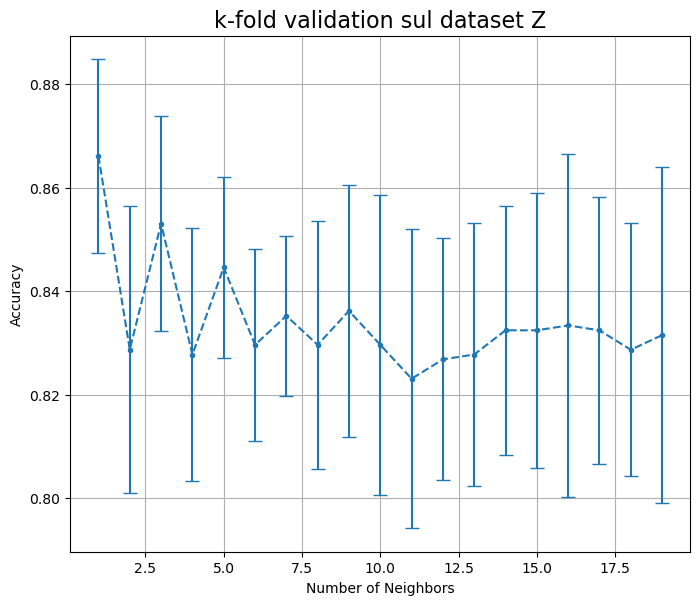

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Cross validation
cv = KFold(n_splits=5, random_state=5, shuffle=True)

performance_means = []
performance_sigmas = []

for k in range(1, 20):
  kn = KNeighborsClassifier(k) # I create an instance of the model
  scores = cross_val_score(kn, Z, y, scoring='accuracy', cv=cv)
  avg = np.mean(scores)
  sigma = np.std(scores)

  performance_means.append(avg)
  performance_sigmas.append(sigma)

plt.figure(figsize=(8,6.7))
plt.errorbar(np.arange(1, 20, 1), performance_means, performance_sigmas, capsize=5, fmt='.--')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('k-fold validation sul dataset Z', size=16)
plt.grid()

From the graph we observe that the best accuracy is obtained for `n_neighbors=3`, since a value of 1 would put us in an edge case.

In [ ]:
# We define the knn algorithm with n_neighbors equal to best_neighbors
best_neighbors = 3
knn = KNeighborsClassifier(n_neighbors=best_neighbors, algorithm='auto')

# Training on the data
knn.fit(Z, y)

# We are interested in the probability that each fragment belongs to a specific class
probabilities = knn.predict_proba(Z_test) # It's an array (71*8, 3)
probabilities = probabilities.reshape(-1,8,3) # We reshape it to (71,8,3)

# In the matrix just shown, the columns represent the probability
# of belonging to one of the 3 classes, respectively Bird, Korean, Arabic.
# The rows instead represent one of the 8 fragments
print('PrababilitÃ  per i frammenti della prima traccia:\n', probabilities[0,:,:])

# We sum over dimension 1, the one of the fragments.
# We obtain an array of shape (71,3), where the rows are the tracks
# and the columns are a number telling us how likely that class is.
probabilities = np.sum(probabilities, axis=1)

# For each row we find the index (0,1,2) representing the entry with the largest number
# This index corresponds to the class index (Bird, Korean, Arabic)
predicted_class = np.argmax(probabilities, axis=1)

PrababilitÃ  per i frammenti della prima traccia:
 [[0.66666667 0.         0.33333333]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [0.33333333 0.33333333 0.33333333]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [0.66666667 0.         0.33333333]]


In [ ]:
# The tracks that anomaly detection had identified are marked with -1
predicted_class[anomaly_indices] = -1

In [ ]:
# We write to a file the track name and its class/anomaly
with open('label_predette.csv','w') as file:
    for i in range(predicted_class.size):
        file.write('{},{}\n'.format(track_names[i], predicted_class[i]))